In [1]:
import matplotlib.pyplot as plt
from collections import defaultdict
import json
import seaborn as sns
import os

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


baseline_mode = 'level_3'
baseline_data_path = 'sample_baseline_data'
exp_data_path = "sample_exp_data"

if not os.path.exists('figures'):
    os.makedirs('figures')

In [2]:

chiplet_array_dims = [(2,2),(2,3),(3,3),(3,4)]
structure='square'
chiplet_size=(7,7)
sparsity = None

exp_depth_data = defaultdict(list)
exp_on_chip_data = defaultdict(list)
exp_cross_chip_data = defaultdict(list)
exp_meas_num_data = defaultdict(list)  
exp_shuttle_num_data = defaultdict(list)
baseline_depth_data = defaultdict(list)
baseline_on_chip_data = defaultdict(list)
baseline_cross_chip_data = defaultdict(list) 

for dim in chiplet_array_dims:
    additional_comment = ''
    if sparsity is not None:
        additional_comment = '_sparsity{}'.format(sparsity)
    baseline_mode_comment = ''
    if baseline_mode == 'level_3':
        baseline_mode_comment = '_level_3'

    s = '_'.join([s[:3] for s in structure.split('_')])
    baseline_file_name = "{}{}{}{}{}{}{}.json".format(s, dim[0], dim[1], chiplet_size[0], chiplet_size[1], additional_comment, baseline_mode_comment)
    exp_file_name = "{}{}{}{}{}{}.json".format(s, dim[0], dim[1], chiplet_size[0], chiplet_size[1], additional_comment)
    baseline_file_path = os.path.join(baseline_data_path, baseline_file_name)
    exp_file_path = os.path.join(exp_data_path, exp_file_name)

    with open(exp_file_path, 'r') as json_file:
        print(exp_file_path)
        exp_data = json.load(json_file)
    for b, data in exp_data.items():
        exp_depth_data[b].append(data['depth'])
        exp_on_chip_data[b].append(data['on-chip'])
        exp_cross_chip_data[b].append(data['cross-chip'])
        exp_meas_num_data[b].append(data['meas_num'])


    with open(baseline_file_path, 'r') as json_file:
        baseline_data = json.load(json_file)[baseline_mode]
        print(baseline_file_path)
    for b, data in baseline_data.items():
        baseline_depth_data[b].append(data['depth'])
        baseline_on_chip_data[b].append(data['on-chip'])
        baseline_cross_chip_data[b].append(data['cross-chip'])

# Print the loaded dictionary
print("Loaded dictionary:", exp_data)
print("Loaded dictionary:", baseline_data)
print(exp_depth_data, baseline_depth_data)

sample_exp_data/squ2277.json
sample_baseline_data/squ2277_level_3.json
sample_exp_data/squ2377.json
sample_baseline_data/squ2377_level_3.json
sample_exp_data/squ3377.json
sample_baseline_data/squ3377_level_3.json
sample_exp_data/squ3477.json
sample_baseline_data/squ3477_level_3.json
Loaded dictionary: {'vqe': {'depth': 13786, 'eff_gate_num': 683377.6, 'on-chip': 532931, 'cross-chip': 8035, 'meas_num': 41358, 'weight': [7.4, 2.2], 'periods': [13, 2], 'shuttle_num': 479, 'sparsity': None}, 'qft': {'depth': 15154, 'eff_gate_num': 808564.8, 'on-chip': 655120, 'cross-chip': 8227, 'meas_num': 42075, 'weight': [7.4, 2.2], 'periods': [13, 2], 'shuttle_num': 479, 'sparsity': None}, 'qaoa': {'depth': 13145, 'eff_gate_num': 536762.6, 'on-chip': 386587, 'cross-chip': 7985, 'meas_num': 41403, 'weight': [7.4, 2.2], 'periods': [13, 2], 'shuttle_num': 478, 'sparsity': None}, 'bv': {'depth': 34, 'eff_gate_num': 1921.1999999999998, 'on-chip': 1344, 'cross-chip': 34, 'meas_num': 148, 'weight': [7.4, 2.2]

In [3]:
import numpy as np

def draw_line_plot_for_scalability():
    chiplet_numbers = [4,6,9,12]
    cross_chip_weight = 7.4
    meas_weight = 2.2
    draw_data = defaultdict(list)
    
    mcms = defaultdict(list)
    mcm_stds = defaultdict(list)
    cnots = defaultdict(list)
    cnots_stds = defaultdict(list)
    remote_cnots = defaultdict(list)
    remote_cnots_stds = defaultdict(list)  

    
    for i, dim in enumerate(chiplet_array_dims):
        mean_cnots = np.mean([exp_on_chip_data[b][i] for b in exp_data.keys()])
        mean_cnots_std = np.std([exp_on_chip_data[b][i] for b in exp_data.keys()])

        mean_mcms = np.mean([exp_meas_num_data[b][i] for b in exp_data.keys()])
        mean_mcms_std = np.std([exp_meas_num_data[b][i] for b in exp_data.keys()])

        mean_remote_cnots = np.mean([exp_cross_chip_data[b][i] for b in exp_data.keys()])
        mean_remote_cnots_std = np.std([exp_cross_chip_data[b][i] for b in exp_data.keys()])

        mcms[chiplet_numbers[i]].append(mean_mcms)
        mcm_stds[chiplet_numbers[i]].append(mean_cnots_std)
        cnots[chiplet_numbers[i]].append(mean_cnots)
        remote_cnots[chiplet_numbers[i]].append(mean_remote_cnots)

    print(mcms)
    print(remote_cnots)
    print(cnots)
    
    with open("mcms.json", "w") as f:
        json.dump(dict(mcms), f, indent=2)
    with open("mcm_stds.json", "w") as f:
        json.dump(dict(mcm_stds), f, indent=2)
    with open("remote_cnots.json", "w") as f:
        json.dump(dict(remote_cnots), f, indent=2)
    with open("remote_cnots_stds.json", "w") as f:
        json.dump(dict(remote_cnots_stds), f, indent=2)
    with open("cnots.json", "w") as f:
        json.dump(dict(cnots), f, indent=2)
    with open("cnots_stds.json", "w") as f:
        json.dump(dict(cnots_stds), f, indent=2)   
    

    
    return mcms, mcm_stds, cnots, cnots_stds, remote_cnots, remote_cnots_stds
 
draw_line_plot_for_scalability()

defaultdict(<class 'list'>, {4: [np.float64(3749.25)], 6: [np.float64(8303.25)], 9: [np.float64(17747.0)], 12: [np.float64(31246.0)]})
defaultdict(<class 'list'>, {4: [np.float64(432.5)], 6: [np.float64(1229.25)], 9: [np.float64(3211.25)], 12: [np.float64(6070.25)]})
defaultdict(<class 'list'>, {4: [np.float64(43557.0)], 6: [np.float64(99714.5)], 9: [np.float64(222059.0)], 12: [np.float64(393995.5)]})


(defaultdict(list,
             {4: [np.float64(3749.25)],
              6: [np.float64(8303.25)],
              9: [np.float64(17747.0)],
              12: [np.float64(31246.0)]}),
 defaultdict(list,
             {4: [np.float64(27017.412228042864)],
              6: [np.float64(62140.43937928022)],
              9: [np.float64(138472.95527105645)],
              12: [np.float64(245824.71599953086)]}),
 defaultdict(list,
             {4: [np.float64(43557.0)],
              6: [np.float64(99714.5)],
              9: [np.float64(222059.0)],
              12: [np.float64(393995.5)]}),
 defaultdict(list, {}),
 defaultdict(list,
             {4: [np.float64(432.5)],
              6: [np.float64(1229.25)],
              9: [np.float64(3211.25)],
              12: [np.float64(6070.25)]}),
 defaultdict(list, {}))

In [4]:
structure='square'
chiplet_array_dim=(3,3)
chiplet_size=(7,7)
sparsity = None

additional_comment = ''
if sparsity is not None:
    additional_comment = '_sparsity{}'.format(sparsity)
baseline_mode_comment = ''
if baseline_mode == 'level_3':
    baseline_mode_comment = '_level_3'

s = '_'.join([s[:3] for s in structure.split('_')])
baseline_file_name = "{}{}{}{}{}{}{}.json".format(s, chiplet_array_dim[0], chiplet_array_dim[1], chiplet_size[0], chiplet_size[1], additional_comment, baseline_mode_comment)
exp_file_name = "{}{}{}{}{}{}.json".format(s, chiplet_array_dim[0], chiplet_array_dim[1], chiplet_size[0], chiplet_size[1], additional_comment)
baseline_file_path = os.path.join(baseline_data_path, baseline_file_name)
exp_file_path = os.path.join(exp_data_path, exp_file_name)

with open(exp_file_path, 'r') as json_file:
    exp_data = json.load(json_file)

exp_depth_data = dict()
exp_on_chip_data = dict()
exp_cross_chip_data = dict()
exp_meas_num_data = dict()  
exp_shuttle_num_data = dict()
for b, data in exp_data.items():
    exp_depth_data[b], exp_on_chip_data[b], exp_cross_chip_data[b], exp_meas_num_data[b], exp_shuttle_num_data[b] = data['depth'], data['on-chip'], data['cross-chip'], data['meas_num'], data['shuttle_num']

with open(baseline_file_path, 'r') as json_file:
    baseline_data = json.load(json_file)[baseline_mode]


baseline_depth_data = dict()
baseline_on_chip_data = dict()
baseline_cross_chip_data = dict() 
for b, data in baseline_data.items():
    baseline_depth_data[b], baseline_on_chip_data[b], baseline_cross_chip_data[b] = data['depth'], data['on-chip'], data['cross-chip']

# Print the loaded dictionary
print("Loaded dictionary:", exp_data)
print("Loaded dictionary:", baseline_data)

Loaded dictionary: {'vqe': {'depth': 10181, 'eff_gate_num': 385647.0, 'on-chip': 301636, 'cross-chip': 4317, 'meas_num': 23666, 'weight': [7.4, 2.2], 'periods': [13, 2], 'shuttle_num': 359, 'sparsity': None}, 'qft': {'depth': 11189, 'eff_gate_num': 451553.2, 'on-chip': 368583, 'cross-chip': 4215, 'meas_num': 23536, 'weight': [7.4, 2.2], 'periods': [13, 2], 'shuttle_num': 359, 'sparsity': None}, 'qaoa': {'depth': 9735, 'eff_gate_num': 300847.2, 'on-chip': 217028, 'cross-chip': 4289, 'meas_num': 23673, 'weight': [7.4, 2.2], 'periods': [13, 2], 'shuttle_num': 357, 'sparsity': None}, 'bv': {'depth': 34, 'eff_gate_num': 1415.1999999999998, 'on-chip': 989, 'cross-chip': 24, 'meas_num': 113, 'weight': [7.4, 2.2], 'periods': [13, 2], 'shuttle_num': 1, 'sparsity': None}}
Loaded dictionary: {'vqe': {'depth': 26277.0, 'eff_gate_num': 471148.24000000005, 'on-chip': 236970.8, 'cross-chip': 31645.6, 'cross_chip_gate_weight': 7.4, 'sparisity': None, 'qubit_num': 360, 'iterations': 5, 'mode': 'level_3

[2, 4, 8, 10]
[np.float64(0.30850442923186766), np.float64(0.2162290044558381), np.float64(0.031678154903778954), np.float64(-0.06059726987225064)]
[43557.0, 99714.5, 222059.0, 393995.5]
[432.5, 1229.25, 3211.25, 6070.25]
[3749.25, 8303.25, 17747.0, 31246.0]
Average 2-q: 189831.5
Average Remote 2-q: 2735.8125
Average MCMs: 15261.375


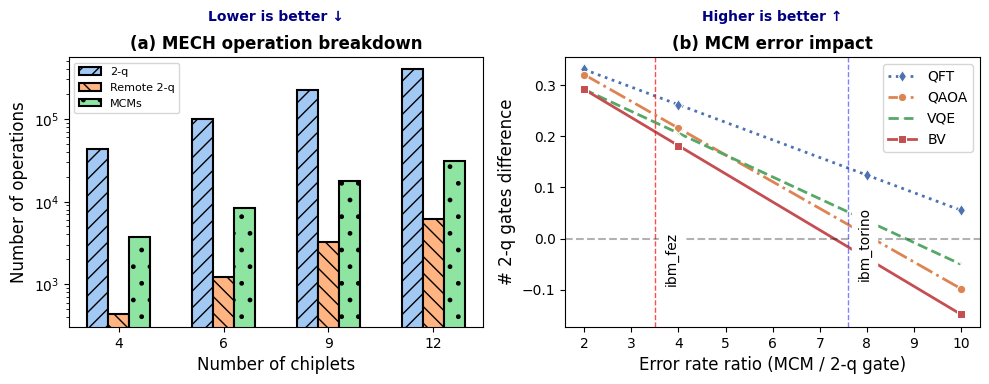

[3.6, 5, 10, 11, 20, 22, 30, 38, 40, 50]
[np.float64(0.6609986420820594), np.float64(0.6314488627079838), np.float64(0.5259139363719998), np.float64(0.504806951104803), np.float64(0.31484408370003175), np.float64(0.2726301131656381), np.float64(0.10377423102806377), np.float64(-0.0650816511095107), np.float64(-0.10729562164390427), np.float64(-0.31836547431587237)]
[2, 2.2, 3, 4, 5, 6, 7, 8, 10.3, 11]
[np.float64(-0.9059676953402654), np.float64(-1.0491558585114922), np.float64(-1.621908511196398), np.float64(-2.3378493270525307), np.float64(-3.0537901429086634), np.float64(-3.769730958764796), np.float64(-4.485671774620928), np.float64(-5.201612590477061), np.float64(-6.848276466946167), np.float64(-7.349435038045458)]


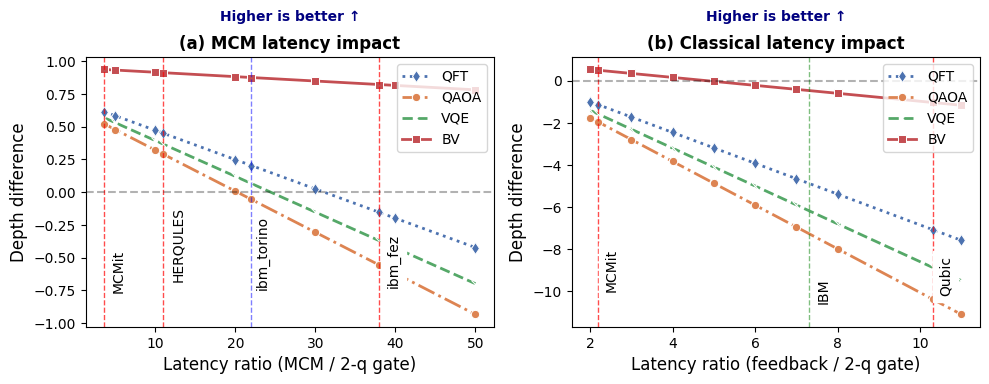

In [17]:
from collections import defaultdict

nrows = 1
ncols = 2

TEXT_WIDTH = 10
THESIS_SIZE = (TEXT_WIDTH, TEXT_WIDTH * 0.4)

fig, ax = plt.subplots(nrows, ncols, figsize=THESIS_SIZE)


cross_chip_weight = 10
meas_weights = [2, 4, 8, 10]
draw_data = defaultdict(list)
for b in exp_data.keys():
    for meas_w in meas_weights:
        exp_eff_cnot = exp_on_chip_data[b] + cross_chip_weight * exp_cross_chip_data[b] + meas_w * exp_meas_num_data[b]
        baseline_eff_cnot = baseline_on_chip_data[b] + cross_chip_weight * baseline_cross_chip_data[b]
        draw_data[b].append(1 - exp_eff_cnot / baseline_eff_cnot)

n_groups = 5
x_data = meas_weights
y_label = '# 2-q gates difference'

colors = sns.color_palette("deep")
    

sns.lineplot(x=x_data, y=draw_data['qft'], linestyle='dotted', linewidth=2, marker='d', color=colors[0], label='QFT', ax=ax[1])
sns.lineplot(x=x_data, y=draw_data['qaoa'], linestyle='dashdot', linewidth=2, marker='o', color=colors[1], label='QAOA', ax=ax[1])
sns.lineplot(x=x_data, y=draw_data['vqe'], linestyle='--', linewidth=2, marker='x', color=colors[2], label='VQE', ax=ax[1])
sns.lineplot(x=x_data, y=draw_data['bv'], linestyle='-', linewidth=2, marker='s', color=colors[3], label='BV', ax=ax[1])

print(x_data)
mean_data = [np.mean([draw_data['qft'][b], draw_data['qaoa'][b], draw_data['vqe'][b], draw_data['bv'][b]]) for b in range(len(draw_data['qft']))]
print(mean_data)

ax[1].set_xlabel('Error rate ratio (MCM / 2-q gate)', fontsize=12)
ax[1].set_ylabel(y_label, fontsize=12)
ax[1].set_title("(b) MCM error impact", fontsize=12, fontweight='bold')

x_pos = 3.5
ax[1].axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax[1].text(
    x=x_pos + 0.2,     # small offset to the right of the line
    y=-0.04,               # y position (midpoint or wherever you want)
    s='ibm_fez',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)

ax[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
x_pos = 7.6
ax[1].axvline(x=x_pos, color='blue', linestyle='--', linewidth=1, alpha=0.5)
ax[1].text(
    x=x_pos + 0.2,     # small offset to the right of the line
    y=-0.01,               # y position (midpoint or wherever you want)
    s='ibm_torino',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)

ax[1].legend(
    fontsize=10,
    loc='upper right'
)

benchmarks = ["vqe", "qaoa", "qft", "bv"]
chiplet_numbers = ['4','6','9','12']


with open("mcms.json", "r") as f:
    mcms = json.load(f)
    
with open("mcm_stds.json", "r") as f:
    mcm_stds = json.load(f)
    
with open("cnots.json", "r") as f:
    cnots = json.load(f)
    
with open("cnots_stds.json", "r") as f:
    cnots_stds = json.load(f)
    
with open("remote_cnots.json", "r") as f:
    remote_cnots = json.load(f)
    
with open("remote_cnots_stds.json", "r") as f:
    remote_cnots_stds = json.load(f)


#for b in chiplet_numbers:
 #   print(mcms[b][0] / remote_cnots[b][0])
    
    
import numpy as np
#benchmarks = list(cnots.keys())
x = np.arange(len(chiplet_numbers))  # for positioning bars

bar_width = 0.2

#print(cnots['4'][0])

print([cnots[b][0] for b in chiplet_numbers])
print([remote_cnots[b][0] for b in chiplet_numbers])
print([mcms[b][0] for b in chiplet_numbers])

average_cnots = np.mean([cnots[b][0] for b in chiplet_numbers])
average_remote_cnots = np.mean([remote_cnots[b][0] for b in chiplet_numbers])
average_mcms = np.mean([mcms[b][0] for b in chiplet_numbers])

print("Average 2-q:", average_cnots)
print("Average Remote 2-q:", average_remote_cnots)
print("Average MCMs:", average_mcms)

colors = sns.color_palette("pastel")
ax[0].bar(x - bar_width, [cnots[b][0] for b in chiplet_numbers], width=bar_width, label="2-q", color=colors[0], hatch='//', edgecolor="black",
           linewidth=1.5,)
ax[0].bar(x, [remote_cnots[b][0] for b in chiplet_numbers], width=bar_width, label="Remote 2-q",  color=colors[1], hatch="\\\\", edgecolor="black",
           linewidth=1.5,)
ax[0].bar(x + bar_width, [mcms[b][0] for b in chiplet_numbers], width=bar_width, label="MCMs",  color=colors[2], hatch=".", edgecolor="black",
           linewidth=1.5,)

ax[0].set_xticks(x)
ax[0].set_xticklabels(chiplet_numbers)
ax[0].set_ylabel("Number of operations", fontsize=12)
ax[0].set_xlabel("Number of chiplets", fontsize=12)
ax[0].set_title("(a) MECH operation breakdown", fontsize=12, fontweight='bold')
ax[0].set_yscale("log")
ax[0].legend(fontsize=8)

ax[0].text(0.5, 1.15, "Lower is better ↓", ha="center", va="center", fontweight="bold", color="navy", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.5, 1.15, "Higher is better ↑", ha="center", va="center", fontweight="bold", color="navy", fontsize=10, transform=ax[1].transAxes)

plt.tight_layout()
plt.savefig('./figures/thesis_mech_analysis_1.pdf', dpi=600)
plt.show()


cross_chip_weight = 10
meas_weight = 2
meas_latencies = [3.6, 5, 10, 11, 20, 22, 30, 38, 40, 50]
draw_data = defaultdict(list)
for b in exp_data.keys():
    for meas_d in meas_latencies:
        exp_depth = exp_depth_data[b] + exp_shuttle_num_data[b] * (meas_d - 2) * 2
        baseline_depth = baseline_depth_data[b]
        draw_data[b].append(1 - exp_depth/baseline_depth)

n_groups = 5
x_data = meas_latencies
y_label = 'Depth difference'

colors = sns.color_palette("deep")

nrows = 1
ncols = 2

TEXT_WIDTH = 10
THESIS_SIZE = (TEXT_WIDTH, TEXT_WIDTH * 0.4)

fig, ax = plt.subplots(nrows, ncols, figsize=THESIS_SIZE)

sns.lineplot(x=x_data, y=draw_data['qft'], linestyle='dotted', linewidth=2, marker='d', color=colors[0], label='QFT', ax=ax[0])
sns.lineplot(x=x_data, y=draw_data['qaoa'], linestyle='dashdot', linewidth=2, marker='o', color=colors[1], label='QAOA', ax=ax[0])
sns.lineplot(x=x_data, y=draw_data['vqe'], linestyle='--', linewidth=2, marker='x', color=colors[2], label='VQE', ax=ax[0])
sns.lineplot(x=x_data, y=draw_data['bv'], linestyle='-', linewidth=2, marker='s', color=colors[3], label='BV', ax=ax[0])

print(x_data)
mean_data = [np.mean([draw_data['qft'][b], draw_data['qaoa'][b], draw_data['vqe'][b], draw_data['bv'][b]]) for b in range(len(draw_data['qft']))]
print(mean_data)

x_pos = 3.6
ax[0].axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax[0].text(
    x=x_pos + 0.9,     # small offset to the right of the line
    y=-0.6,               # y position (midpoint or wherever you want)
    s='MCMit',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)

x_pos = 11
ax[0].axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax[0].text(
    x=x_pos + 1,     # small offset to the right of the line
    y=-0.4,               # y position (midpoint or wherever you want)
    s='HERQULES',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)



x_pos = 38
ax[0].axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax[0].text(
    x=x_pos + 0.9,     # small offset to the right of the line
    y=-0.52,               # y position (midpoint or wherever you want)
    s='ibm_fez',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)

ax[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
x_pos = 22

ax[0].axvline(x=x_pos, color='blue', linestyle='--', linewidth=1, alpha=0.5)
ax[0].text(
    x=x_pos + 0.5,     # small offset to the right of the line
    y=-0.46,               # y position (midpoint or wherever you want)
    s='ibm_torino',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    #backgroundcolor='white',  # optional: make it readable
    fontsize=10
)

ax[0].set_title("(a) MCM latency impact", fontsize=12, fontweight='bold')

#plt.xticks(x_data, fontsize=13, fontweight='bold')
#plt.yticks(fontsize=13, fontweight='bold')
ax[0].legend(
    fontsize=10,
    loc='upper right',
)
ax[0].set_xlabel('Latency ratio (MCM / 2-q gate)', fontsize=12)
ax[0].set_ylabel(y_label, fontsize=12)

cross_chip_weight = 10
meas_weight = 2
meas_latency = 10
classical_latencies = [2, 2.2,  3, 4, 5, 6, 7, 8, 10.3, 11]

draw_data = defaultdict(list)
for b in exp_data.keys():
    for c_l in classical_latencies:
        exp_depth = exp_depth_data[b] + exp_shuttle_num_data[b] * (meas_latency - 2) * 2 + exp_meas_num_data[b] * c_l
        baseline_depth = baseline_depth_data[b]
        draw_data[b].append(1 - exp_depth/baseline_depth)

n_groups = 5
x_data = classical_latencies
y_label = 'Depth difference'
    

sns.lineplot(x=x_data, y=draw_data['qft'], linestyle='dotted', linewidth=2, marker='d', color=colors[0], label='QFT', ax=ax[1])
sns.lineplot(x=x_data, y=draw_data['qaoa'], linestyle='dashdot', linewidth=2, marker='o', color=colors[1], label='QAOA', ax=ax[1])
sns.lineplot(x=x_data, y=draw_data['vqe'], linestyle='--', linewidth=2, marker='x', color=colors[2], label='VQE', ax=ax[1])
sns.lineplot(x=x_data, y=draw_data['bv'], linestyle='-', linewidth=2, marker='s', color=colors[3], label='BV', ax=ax[1])

print(x_data)
mean_data = [np.mean([draw_data['qft'][b], draw_data['qaoa'][b], draw_data['vqe'][b], draw_data['bv'][b]]) for b in range(len(draw_data['qft']))]
print(mean_data)

x_pos = 2.2
ax[1].axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax[1].text(
    x=x_pos + 0.15,     # small offset to the right of the line
    y=-9,               # y position (midpoint or wherever you want)
    s='MCMit',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)

x_pos = 10.3
ax[1].axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax[1].text(
    x=x_pos + 0.15,     # small offset to the right of the line
    y=-9.3,               # y position (midpoint or wherever you want)
    s='Qubic',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)


x_pos = 7.3
ax[1].axvline(x=x_pos, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax[1].text(
    x=x_pos + 0.2,     # small offset to the right of the line
    y=-10,               # y position (midpoint or wherever you want)
    s='IBM',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)
ax[1].set_title("(b) Classical latency impact", fontsize=12, fontweight='bold')

#ax[2].xticks(x_data, fontsize=12, fontweight='bold')
#ax[2].yticks(fontsize=13, fontweight='bold')
ax[1].legend(
    fontsize=10, 
    loc='upper right',
    
)
ax[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax[1].set_xlabel('Latency ratio (feedback / 2-q gate)', fontsize=12)
ax[1].set_ylabel(y_label, fontsize=12)

ax[0].text(0.5, 1.15, "Higher is better ↑", ha="center", va="center", fontweight="bold", color="navy", fontsize=10, transform=ax[0].transAxes)
ax[1].text(0.5, 1.15, "Higher is better ↑", ha="center", va="center", fontweight="bold", color="navy", fontsize=10, transform=ax[1].transAxes)

plt.tight_layout()
plt.savefig('./figures/thesis_mech_analysis_2.pdf', dpi=600)
plt.show()

In [ ]:

cross_chip_weight = 10
meas_weight = 2
meas_latency = 10
classical_latencies = [2, 2.2, 3, 4, 5, 5.6, 6, 7, 8]

draw_data = defaultdict(list)
for b in exp_data.keys():
    for c_l in classical_latencies:
        exp_depth = exp_depth_data[b] + exp_shuttle_num_data[b] * (meas_latency - 2) * 2 + exp_meas_num_data[b] * c_l
        baseline_depth = baseline_depth_data[b]
        draw_data[b].append(1 - exp_depth/baseline_depth)

n_groups = 5
x_data = classical_latencies
y_label = 'Depth improvement'
    

sns.lineplot(x=x_data, y=draw_data['qft'], linestyle='dotted', linewidth=2, marker='d', color=colors[0], label='QFT', ax=ax[3])
sns.lineplot(x=x_data, y=draw_data['qaoa'], linestyle='dashdot', linewidth=2, marker='o', color=colors[1], label='QAOA', ax=ax[3])
sns.lineplot(x=x_data, y=draw_data['vqe'], linestyle='--', linewidth=2, marker='x', color=colors[2], label='VQE', ax=ax[3])
sns.lineplot(x=x_data, y=draw_data['bv'], linestyle='-', linewidth=2, marker='s', color=colors[3], label='BV', ax=ax[3])

#ax.plot(x_data, draw_data['qft'], linestyle='dotted', linewidth=2, marker='d', color=green, label='QFT')
#ax.plot(x_data, draw_data['qaoa'], linestyle='dashdot', linewidth=2, marker='o', color=blue, label='OAQA')
#ax.plot(x_data, draw_data['vqe'], linestyle='--', linewidth=2, marker='x', color=yellow, label='VQE')
#ax.plot(x_data, draw_data['bv'], linestyle='-', linewidth=2, marker='s', color=red, label='BV')
#ax.set_xscale("log", base=2)

x_pos = 2.2
ax[3].axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax[3].text(
    x=x_pos + 0.1,     # small offset to the right of the line
    y=-7.5,               # y position (midpoint or wherever you want)
    s='MCMit',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=8
)

x_pos = 5.6
ax[3].axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax[3].text(
    x=x_pos + 0.1,     # small offset to the right of the line
    y=-7.5,               # y position (midpoint or wherever you want)
    s='Qubic',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=8
)

x_pos = 7.3
ax[3].axvline(x=x_pos, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax[3].text(
    x=x_pos + 0.1,     # small offset to the right of the line
    y=-7.6,               # y position (midpoint or wherever you want)
    s='IBM',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=8
)
ax[3].set_title("Measurement / local CNOT latency ratio: " + str(meas_latency), fontsize=12, fontweight='bold')

#ax[3].xticks(x_data, fontsize=12, fontweight='bold')
#ax[3].yticks(fontsize=13, fontweight='bold')
ax[3].legend(fontsize=10, loc="upper right")

ax[3].set_xlabel('Latency ratio (classical feedback / local CNOT)', fontsize=12)
ax[3].set_ylabel(y_label, fontsize=12)

plt.tight_layout()
plt.savefig('./figures/sensitivity_d.png', dpi=300)
plt.show()

IndexError: index 3 is out of bounds for axis 0 with size 2

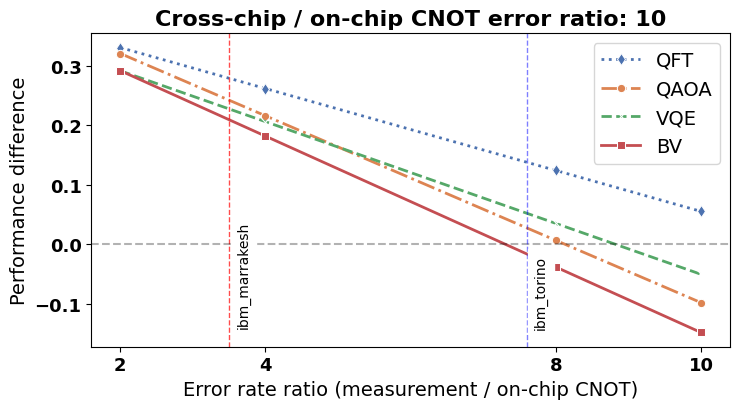

In [7]:
cross_chip_weight = 10
meas_weights = [2, 4, 8, 10]
draw_data = defaultdict(list)
for b in exp_data.keys():
    for meas_w in meas_weights:
        exp_eff_cnot = exp_on_chip_data[b] + cross_chip_weight * exp_cross_chip_data[b] + meas_w * exp_meas_num_data[b]
        baseline_eff_cnot = baseline_on_chip_data[b] + cross_chip_weight * baseline_cross_chip_data[b]
        draw_data[b].append(1 - exp_eff_cnot / baseline_eff_cnot)

n_groups = 5
x_data = meas_weights
y_label = 'Performance difference'

green, blue, red, yellow = '#2CA02C', '#1F77B4', '#FF7F0E', '#FFC000'
colors = sns.color_palette("deep")
    
fig, ax = plt.subplots(figsize=(7.5, 4.2))

sns.lineplot(x=x_data, y=draw_data['qft'], linestyle='dotted', linewidth=2, marker='d', color=colors[0], label='QFT')
sns.lineplot(x=x_data, y=draw_data['qaoa'], linestyle='dashdot', linewidth=2, marker='o', color=colors[1], label='QAOA')
sns.lineplot(x=x_data, y=draw_data['vqe'], linestyle='--', linewidth=2, marker='x', color=colors[2], label='VQE')
sns.lineplot(x=x_data, y=draw_data['bv'], linestyle='-', linewidth=2, marker='s', color=colors[3], label='BV')

#ax.plot(x_data, draw_data['qft'], linestyle='dotted', linewidth=2, marker='d', color=green, label='QFT')
#ax.plot(x_data, draw_data['qaoa'], linestyle='dashdot', linewidth=2, marker='o', color=blue, label='QAOA')
#ax.plot(x_data, draw_data['vqe'], linestyle='--', linewidth=2, marker='x', color=yellow, label='VQE')
#ax.plot(x_data, draw_data['bv'], linestyle='-', linewidth=2, marker='s', color=red, label='BV')

plt.xticks(x_data, fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
ax.set_xlabel('Error rate ratio (measurement / on-chip CNOT)', fontsize=14)
ax.set_ylabel(y_label, fontsize=14)
ax.set_title("Cross-chip / on-chip CNOT error ratio: " + str(cross_chip_weight), fontsize=16, fontweight='bold')

x_pos = 3.5
ax.axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.text(
    x=x_pos + 0.1,     # small offset to the right of the line
    y=-0.05,               # y position (midpoint or wherever you want)
    s='ibm_marrakesh',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
x_pos = 7.6
ax.axvline(x=x_pos, color='blue', linestyle='--', linewidth=1, alpha=0.5)
plt.text(
    x=x_pos + 0.1,     # small offset to the right of the line
    y=-0.08,               # y position (midpoint or wherever you want)
    s='ibm_torino',
    rotation=90,       # rotate text vertically
    va='center',       # vertical alignment
    ha='left',         # horizontal alignment
    backgroundcolor='white',  # optional: make it readable
    fontsize=10
)



plt.legend(fontsize=14, loc='upper right')


plt.tight_layout()
plt.savefig('./figures/sensitivity_b.png', dpi=300)
plt.show()

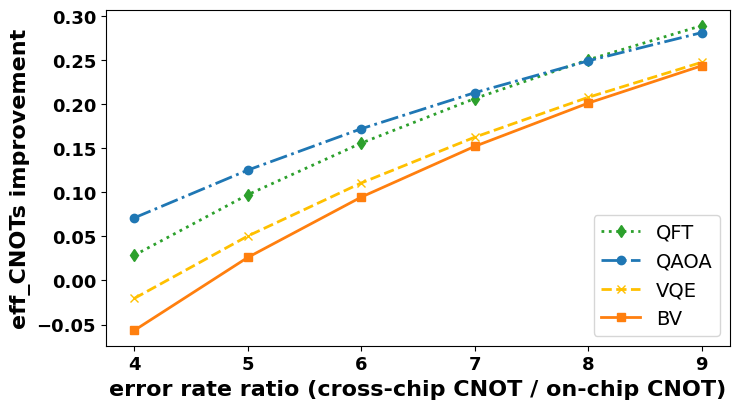

In [8]:
cross_chip_weights = [4,5,6,7,8,9]
meas_weight = 2.2
draw_data = defaultdict(list)
for b in exp_data.keys():
    for cross_w in cross_chip_weights:
        exp_eff_cnot = exp_on_chip_data[b] + cross_w * exp_cross_chip_data[b] + meas_weight * exp_meas_num_data[b]
        baseline_eff_cnot = baseline_on_chip_data[b] + cross_w * baseline_cross_chip_data[b]
        draw_data[b].append(1 - exp_eff_cnot / baseline_eff_cnot)

n_groups = 5
x_data = cross_chip_weights
y_label = 'eff_CNOTs improvement'

green, blue, red, yellow = '#2CA02C', '#1F77B4', '#FF7F0E', '#FFC000'
    
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x_data, draw_data['qft'], linestyle='dotted', linewidth=2, marker='d', color=green, label='QFT')
ax.plot(x_data, draw_data['qaoa'], linestyle='dashdot', linewidth=2, marker='o', color=blue, label='QAOA')
ax.plot(x_data, draw_data['vqe'], linestyle='--', linewidth=2, marker='x', color=yellow, label='VQE')
ax.plot(x_data, draw_data['bv'], linestyle='-', linewidth=2, marker='s', color=red, label='BV')

plt.xticks(x_data, fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.legend(fontsize=14, loc='lower right')
ax.set_xlabel('error rate ratio (cross-chip CNOT / on-chip CNOT)', fontsize=16, fontweight='bold')
ax.set_ylabel(y_label, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./figures/sensitivity_c.pdf')
plt.show()